# **Data Visualization** for Order Dataset

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Load dataset
df = pd.read_excel("CleanOrdersData.xlsx")

# View first rows
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,Year,Month,Day,DayOfWeek,PriceCategory,WeekNum
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10,2023,1,4,Wednesday,High,1
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70,2024,8,23,Friday,Low,34
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40,2024,2,27,Tuesday,High,9
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19,2023,10,15,Sunday,Low,41
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04,2025,5,8,Thursday,High,19


In [ ]:
print(df.shape)

print(df.info())


(1200, 20)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object        
 8   OrderStatus      1200 non-null   object        
 9   TrackingNumber   1200 non-null   object        
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       1200 non-null   object        
 12  ReferralSource   1200 non-null   object        
 13  TotalPrice       1200 non-null   float64       
 14  Year             1200 non-nul

In [4]:
print(df.describe())

                      Date     Quantity    UnitPrice  ItemsInCart  \
count                 1200  1200.000000  1200.000000  1200.000000   
mean   2024-03-22 16:58:48     2.945833   356.412750     5.485000   
min    2023-01-01 00:00:00     1.000000    11.390000     1.000000   
25%    2023-08-03 18:00:00     2.000000   186.062500     4.000000   
50%    2024-03-23 00:00:00     3.000000   364.210000     5.000000   
75%    2024-11-08 12:00:00     4.000000   521.570000     7.000000   
max    2025-06-30 00:00:00     5.000000   699.930000    10.000000   
std                    NaN     1.407557   197.177146     2.281983   

        TotalPrice         Year        Month          Day      WeekNum  
count  1200.000000  1200.000000  1200.000000  1200.000000  1200.000000  
mean   1053.968300  2023.767500     5.995000    15.969167    24.413333  
min      11.390000  2023.000000     1.000000     1.000000     1.000000  
25%     410.520000  2023.000000     3.000000     8.000000    12.000000  
50%     823.6

In [5]:
df.isnull().sum()

OrderID            0
Date               0
CustomerID         0
Product            0
Quantity           0
UnitPrice          0
ShippingAddress    0
PaymentMethod      0
OrderStatus        0
TrackingNumber     0
ItemsInCart        0
CouponCode         0
ReferralSource     0
TotalPrice         0
Year               0
Month              0
Day                0
DayOfWeek          0
PriceCategory      0
WeekNum            0
dtype: int64

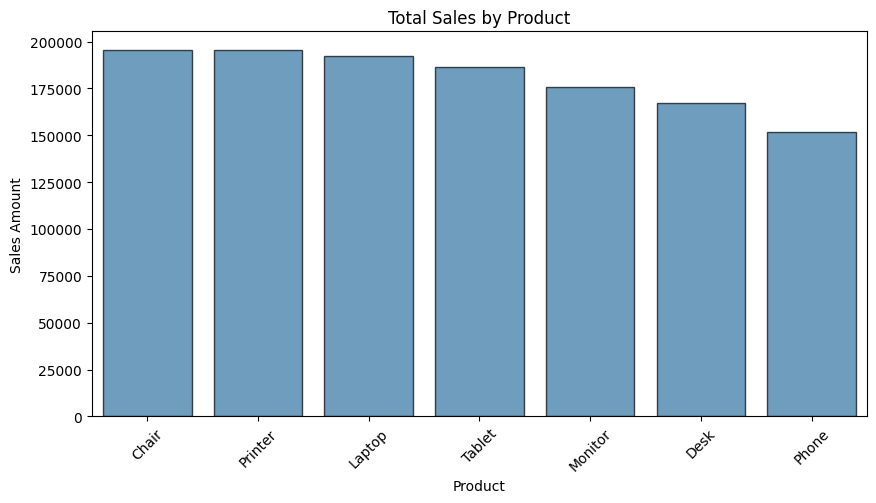

In [20]:

# Aggregate sales by product
product_sales = df.groupby('Product')['TotalPrice'].sum().reset_index()

# Sort in descending order
product_sales = product_sales.sort_values(by='TotalPrice', ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(data=product_sales, x='Product', y='TotalPrice', edgecolor='black',linewidth=1,alpha=0.7)

plt.title('Total Sales by Product')
plt.xlabel('Product')
plt.xticks(rotation=45)
plt.ylabel('Sales Amount')
plt.show()


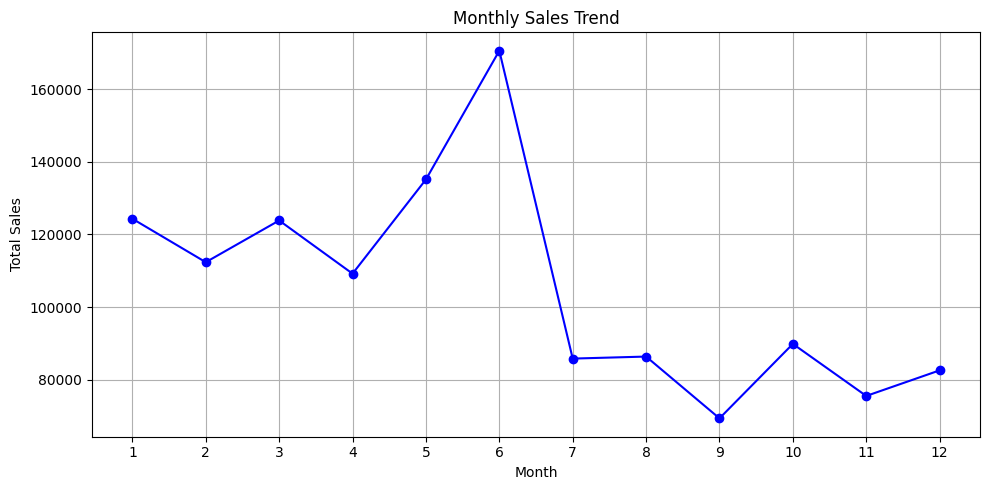

In [ ]:
monthly_sales = df.groupby('Month')['TotalPrice'].sum()

plt.figure(figsize=(10,5))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o', linestyle='-', color='blue')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.grid(True)
plt.xticks(range(1, 13)) 
plt.tight_layout()
plt.show()

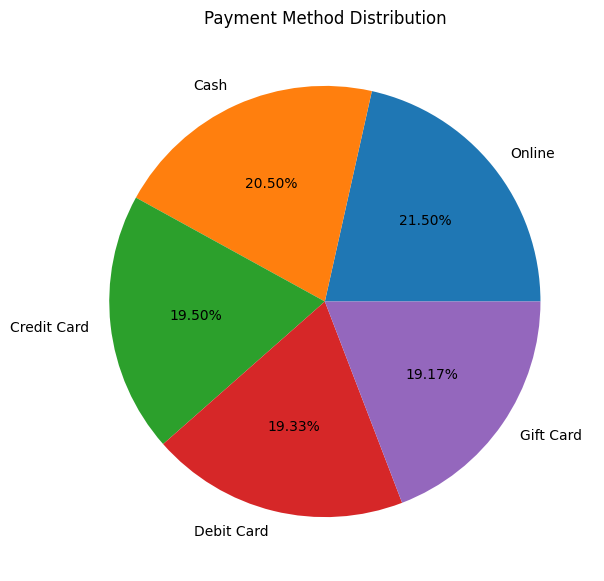

In [35]:
payment_counts = df['PaymentMethod'].value_counts()

plt.figure(figsize=(7,7))

plt.pie(payment_counts, labels=payment_counts.index, autopct='%1.2f%%')

plt.title('Payment Method Distribution')

plt.show()

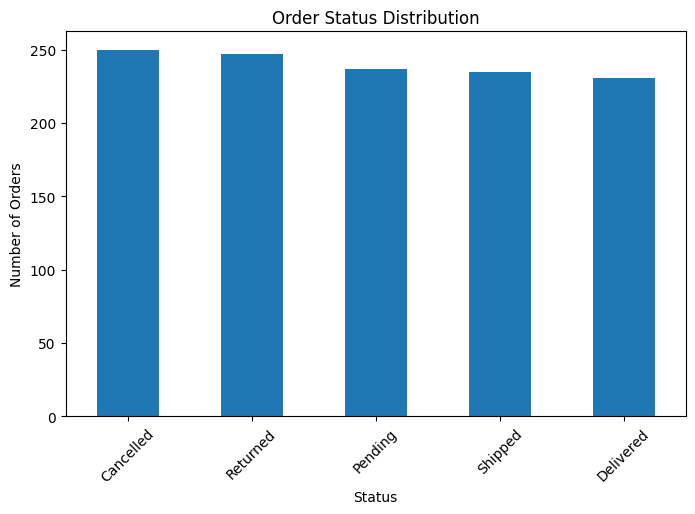

In [37]:
status_counts = df['OrderStatus'].value_counts()

plt.figure(figsize=(8,5))

status_counts.plot(kind='bar')

plt.title('Order Status Distribution')
plt.xlabel('Status')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.show()

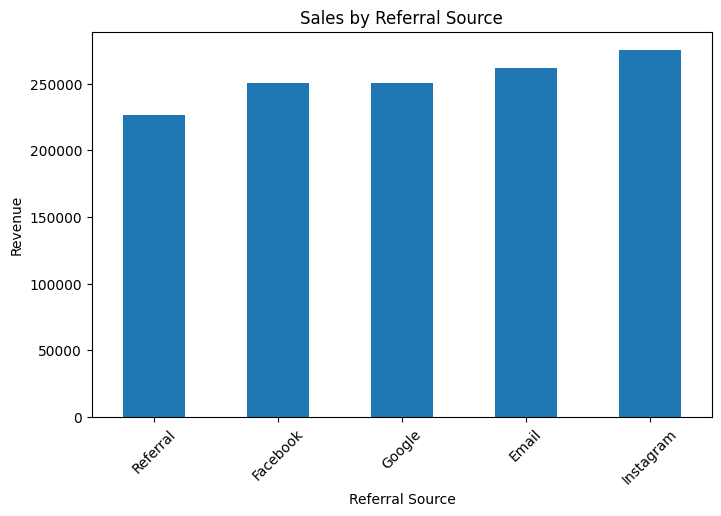

In [39]:
referral_sales = df.groupby('ReferralSource')['TotalPrice'].sum()

plt.figure(figsize=(8,5))

referral_sales.sort_values().plot(kind='bar')

plt.title('Sales by Referral Source')
plt.xlabel('Referral Source')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.show()

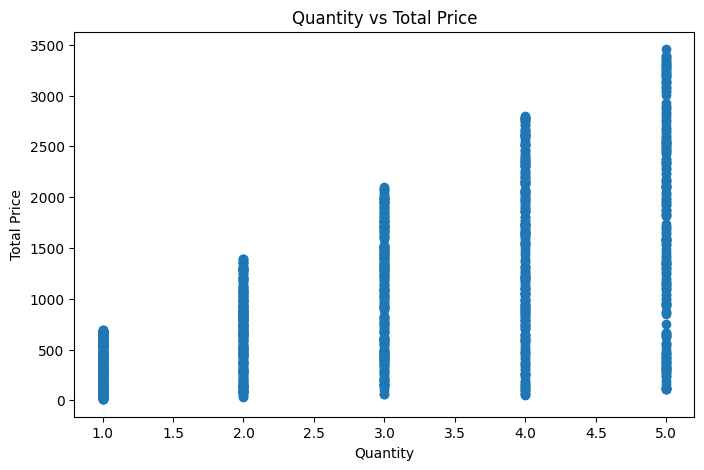

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(df['Quantity'], df['TotalPrice'])

plt.title('Quantity vs Total Price')
plt.xlabel('Quantity')
plt.ylabel('Total Price')
plt.show()